# Importation des bibliothèques

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score,train_test_split,GridSearchCV
from xgboost import XGBClassifier


# Visualisation du jeu de données

In [13]:
def read_data():
    data_score_credit = pd.read_csv('../data/cs-training.csv')
    return data_score_credit

In [14]:
data_score_credit = read_data()
data_score_credit.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Renommage des colonnes pour qu'elles soient plus compréhensible.

In [15]:
data_score_credit.rename(columns={'SeriousDlqin2yrs': 'target',
                         'RevolvingUtilizationOfUnsecuredLines': 'taux_utilisation_credit',
                         'age': 'age',
                         'NumberOfTime30-59DaysPastDueNotWorse': 'nbr_30-59_jours_retard',
                         'DebtRatio': 'ratio_endettement',
                         'MonthlyIncome':'Revenus_mensuel', 
                         'NumberOfOpenCreditLinesAndLoans':'nbr_lignes_credit_ouvertes',
                         'NumberOfTimes90DaysLate': 'nbr_90_jours_retard',
                         'NumberRealEstateLoansOrLines': 'nbr_prets_immobilier',
                         'NumberOfTime60-89DaysPastDueNotWorse':'nbr_60-89_jours_retard',
                        'NumberOfDependents' : 'nbr_person_foyer'
                        

                         }, inplace=True)

data_score_credit.head()

,Unnamed: 0,target,taux_utilisation_credit,age,nbr_30-59_jours_retard,ratio_endettement,Revenus_mensuel,nbr_lignes_credit_ouvertes,nbr_90_jours_retard,nbr_prets_immobilier,nbr_60-89_jours_retard,nbr_person_foyer
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Visualisation des méta données

In [16]:
data_score_credit.isnull().sum()

Unnamed: 0                        0
target                            0
taux_utilisation_credit           0
age                               0
nbr_30-59_jours_retard            0
ratio_endettement                 0
Revenus_mensuel               29731
nbr_lignes_credit_ouvertes        0
nbr_90_jours_retard               0
nbr_prets_immobilier              0
nbr_60-89_jours_retard            0
nbr_person_foyer               3924
dtype: int64

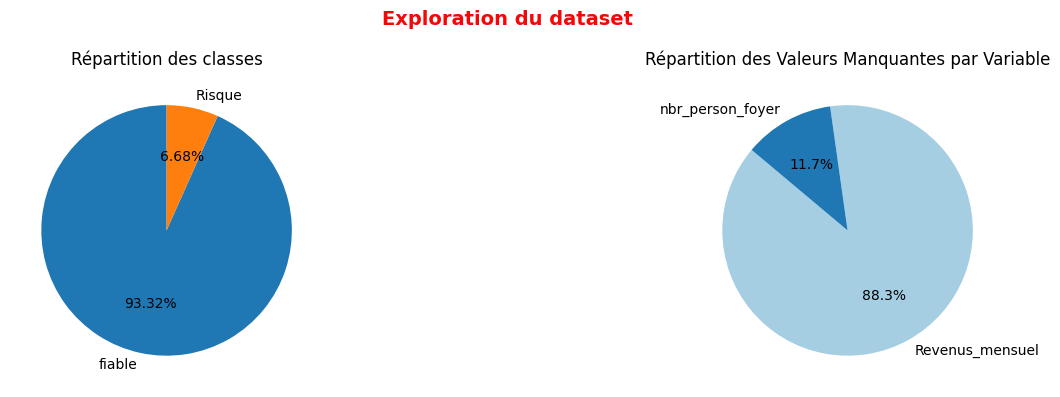

In [17]:
target = data_score_credit['target'].value_counts()
valeur_manquante = data_score_credit.isnull().sum()
seul_valeur_manquante = valeur_manquante[valeur_manquante > 0]
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("Exploration du dataset", color="#f40707", fontsize=14, fontweight='bold')

# Pie fraude
labels_pie = ['fiable', 'Risque']

axes[0].pie([target[0], target[1]], labels=labels_pie,
            autopct='%1.2f%%', startangle=90)
axes[0].set_title("Répartition des classes")


axes[1].pie(
        seul_valeur_manquante, 
        labels=seul_valeur_manquante.index, 
        autopct='%1.1f%%', # Affiche le pourcentage sur le cercle
        startangle=140, 
        colors=plt.cm.Paired.colors # Utilise une palette de couleurs variées
    )
axes[1].set_title("Répartition des Valeurs Manquantes par Variable")

plt.tight_layout()
plt.show()

age moyen pour prendre le credit est de 52.295206666666665
target
0    6.168855
1    4.367282
Name: taux_utilisation_credit, dtype: float64


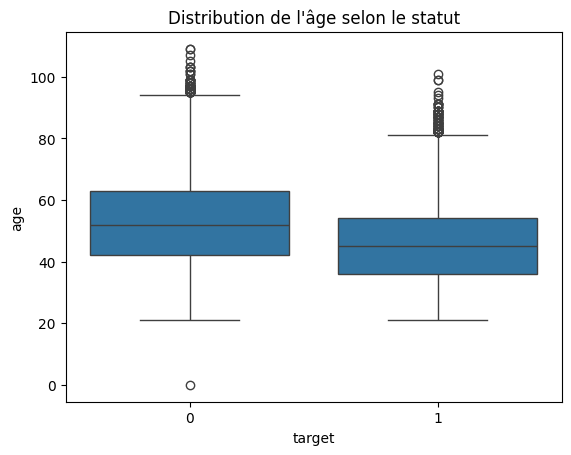

In [18]:
# 1. Vérifier le déséquilibre de la cible
print(f"age moyen pour prendre le credit est de {data_score_credit['age'].mean()}")

# 2. Comparer la moyenne du taux d'utilisation du crédit selon la cible
print(data_score_credit.groupby('target')['taux_utilisation_credit'].mean())


sns.boxplot(x='target', y='age', data=data_score_credit)
plt.title("Distribution de l'âge selon le statut")
plt.show()

# distribution des personnes qui prennent le plus du credit et pourquoi?

In [19]:
# 1. Calculer la médiane des revenus sur les données existantes
mediane_revenu = data_score_credit['Revenus_mensuel'].median()

# 2. Appliquer les remplacements
data_score_credit['Revenus_mensuel'] = data_score_credit['Revenus_mensuel'].fillna(mediane_revenu)
data_score_credit['nbr_person_foyer'] = data_score_credit['nbr_person_foyer'].fillna(0)
# On ne conserve que les lignes où l'âge est strictement supérieur à 17 ans
data_score_credit = data_score_credit[data_score_credit['age'] >= 18]

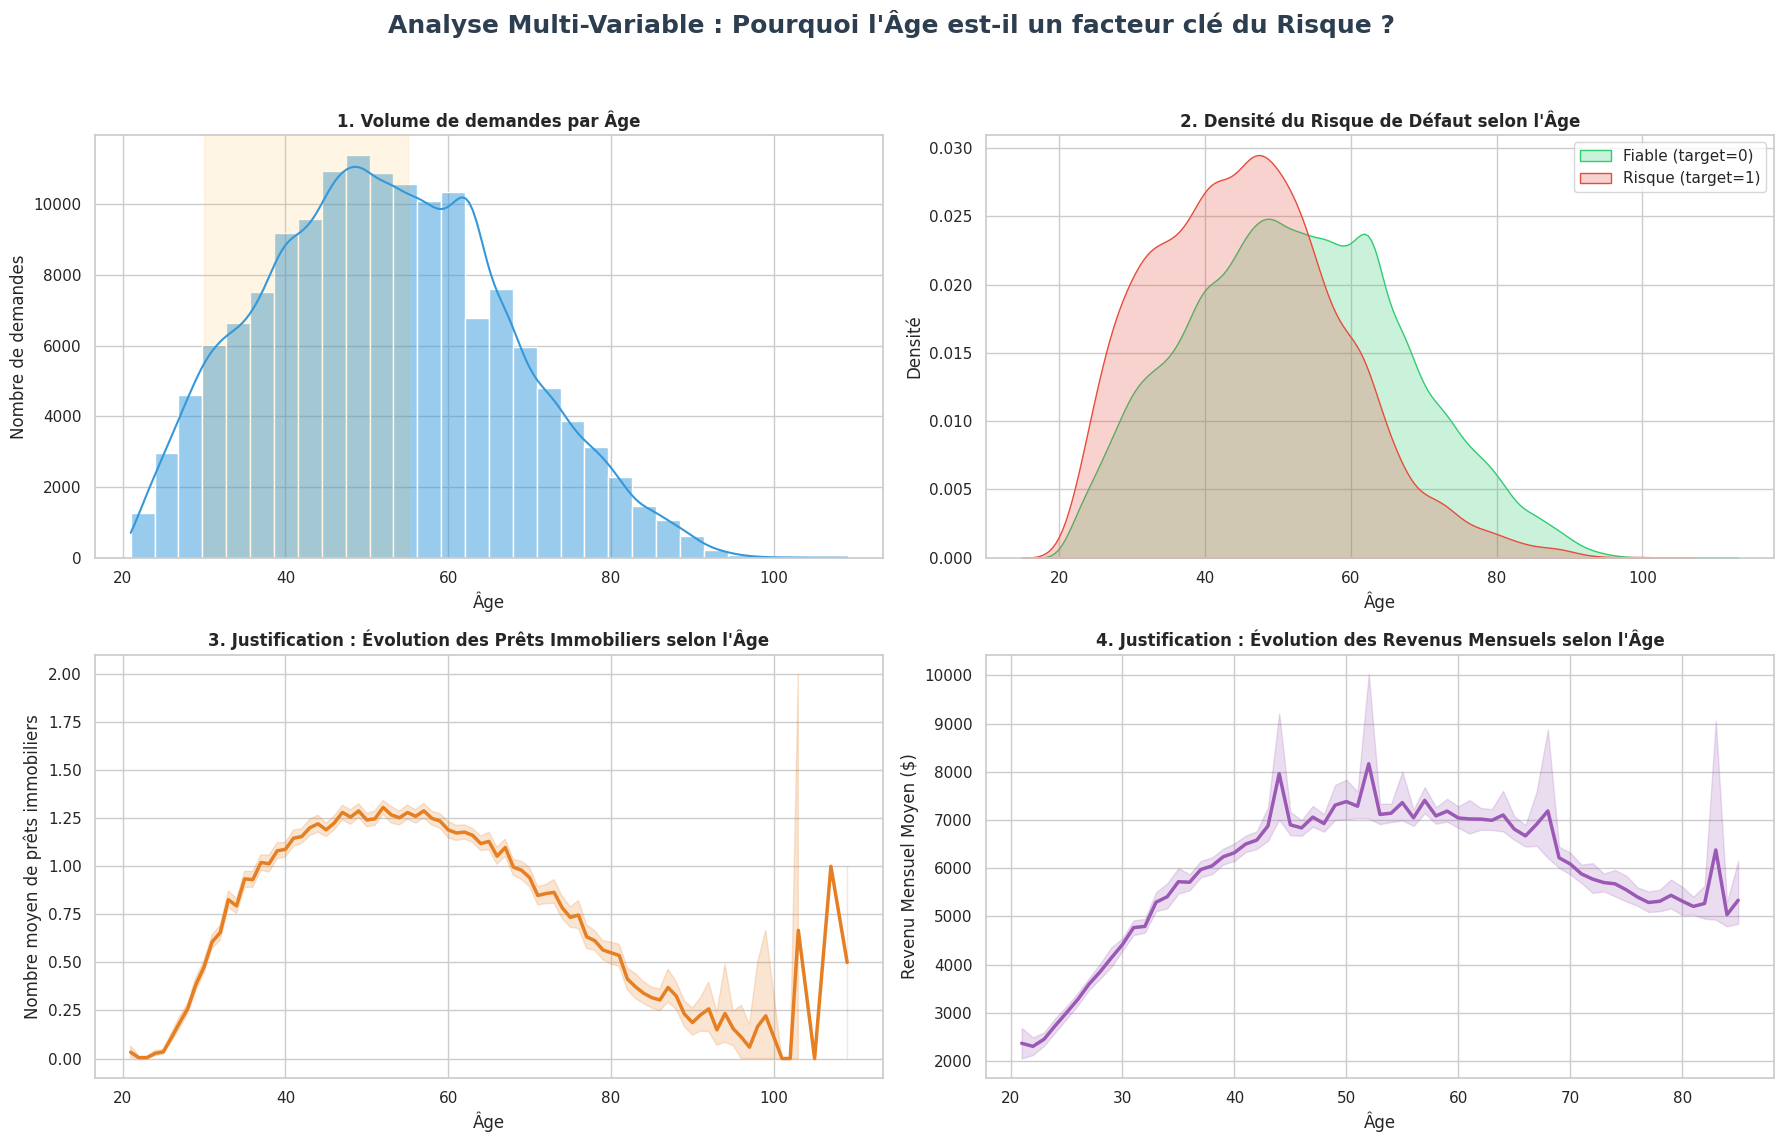

In [20]:
# Configurer le style des graphiques
sns.set_theme(style="whitegrid")

# On passe à 2 lignes, 2 colonnes
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Analyse Multi-Variable : Pourquoi l'Âge est-il un facteur clé du Risque ?", 
             fontsize=18, fontweight='bold', color='#2c3e50', y=0.95)

# --- [0, 0] En haut à gauche : Distribution Globale ---
sns.histplot(data=data_score_credit, x='age', kde=True, bins=30, color='#3498db', ax=axes[0, 0])
axes[0, 0].set_title("1. Volume de demandes par Âge", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Âge")
axes[0, 0].set_ylabel("Nombre de demandes")
axes[0, 0].axvspan(30, 55, color='orange', alpha=0.1, label="Tranche active")

# --- [0, 1] En haut à droite : Densité du Risque ---
sns.kdeplot(data=data_score_credit[data_score_credit['target'] == 0], x='age', label='Fiable (target=0)', fill=True, color='#2ecc71', ax=axes[0, 1])
sns.kdeplot(data=data_score_credit[data_score_credit['target'] == 1], x='age', label='Risque (target=1)', fill=True, color='#e74c3c', ax=axes[0, 1])
axes[0, 1].set_title("2. Densité du Risque de Défaut selon l'Âge", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Âge")
axes[0, 1].set_ylabel("Densité")
axes[0, 1].legend()

# --- [1, 0] En bas à gauche : Justification 1 (Prêts Immobiliers) ---
# On regarde le nombre moyen de prêts immobiliers par tranche d'âge
sns.lineplot(data=data_score_credit, x='age', y='nbr_prets_immobilier', color='#e67e22', lw=2.5, ax=axes[1, 0])
axes[1, 0].set_title("3. Justification : Évolution des Prêts Immobiliers selon l'Âge", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Âge")
axes[1, 0].set_ylabel("Nombre moyen de prêts immobiliers")

# --- [1, 1] En bas à droite : Justification 2 (Revenus Mensuels) ---
# On utilise un lineplot (ou un barplot regroupé) pour voir la tendance des revenus sans se faire polluer par les valeurs extrêmes
# Note : On limite l'affichage à l'âge de 18 à 85 ans pour une meilleure visibilité de la courbe
sns.lineplot(data=data_score_credit[data_score_credit['age'] <= 85], x='age', y='Revenus_mensuel', color='#9b59b6', lw=2.5, ax=axes[1, 1])
axes[1, 1].set_title("4. Justification : Évolution des Revenus Mensuels selon l'Âge", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Âge")
axes[1, 1].set_ylabel("Revenu Mensuel Moyen ($)")

# Ajustement parfait des espaces pour éviter les chevauchements
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# surendettement et la capacité de remboursement.

/tmp/ipykernel_1491666/1084844544.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_analyse, x='tranche_age', y='ratio_endettement', palette='Blues_d', ax=axes[0, 0])
/tmp/ipykernel_1491666/1084844544.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_analyse[df_analyse['nbr_person_foyer'] <= 5], x='nbr_person_foyer', y='ratio_endettement', palette='Purples_d', ax=axes[0, 1])
/tmp/ipykernel_1491666/1084844544.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df_ana

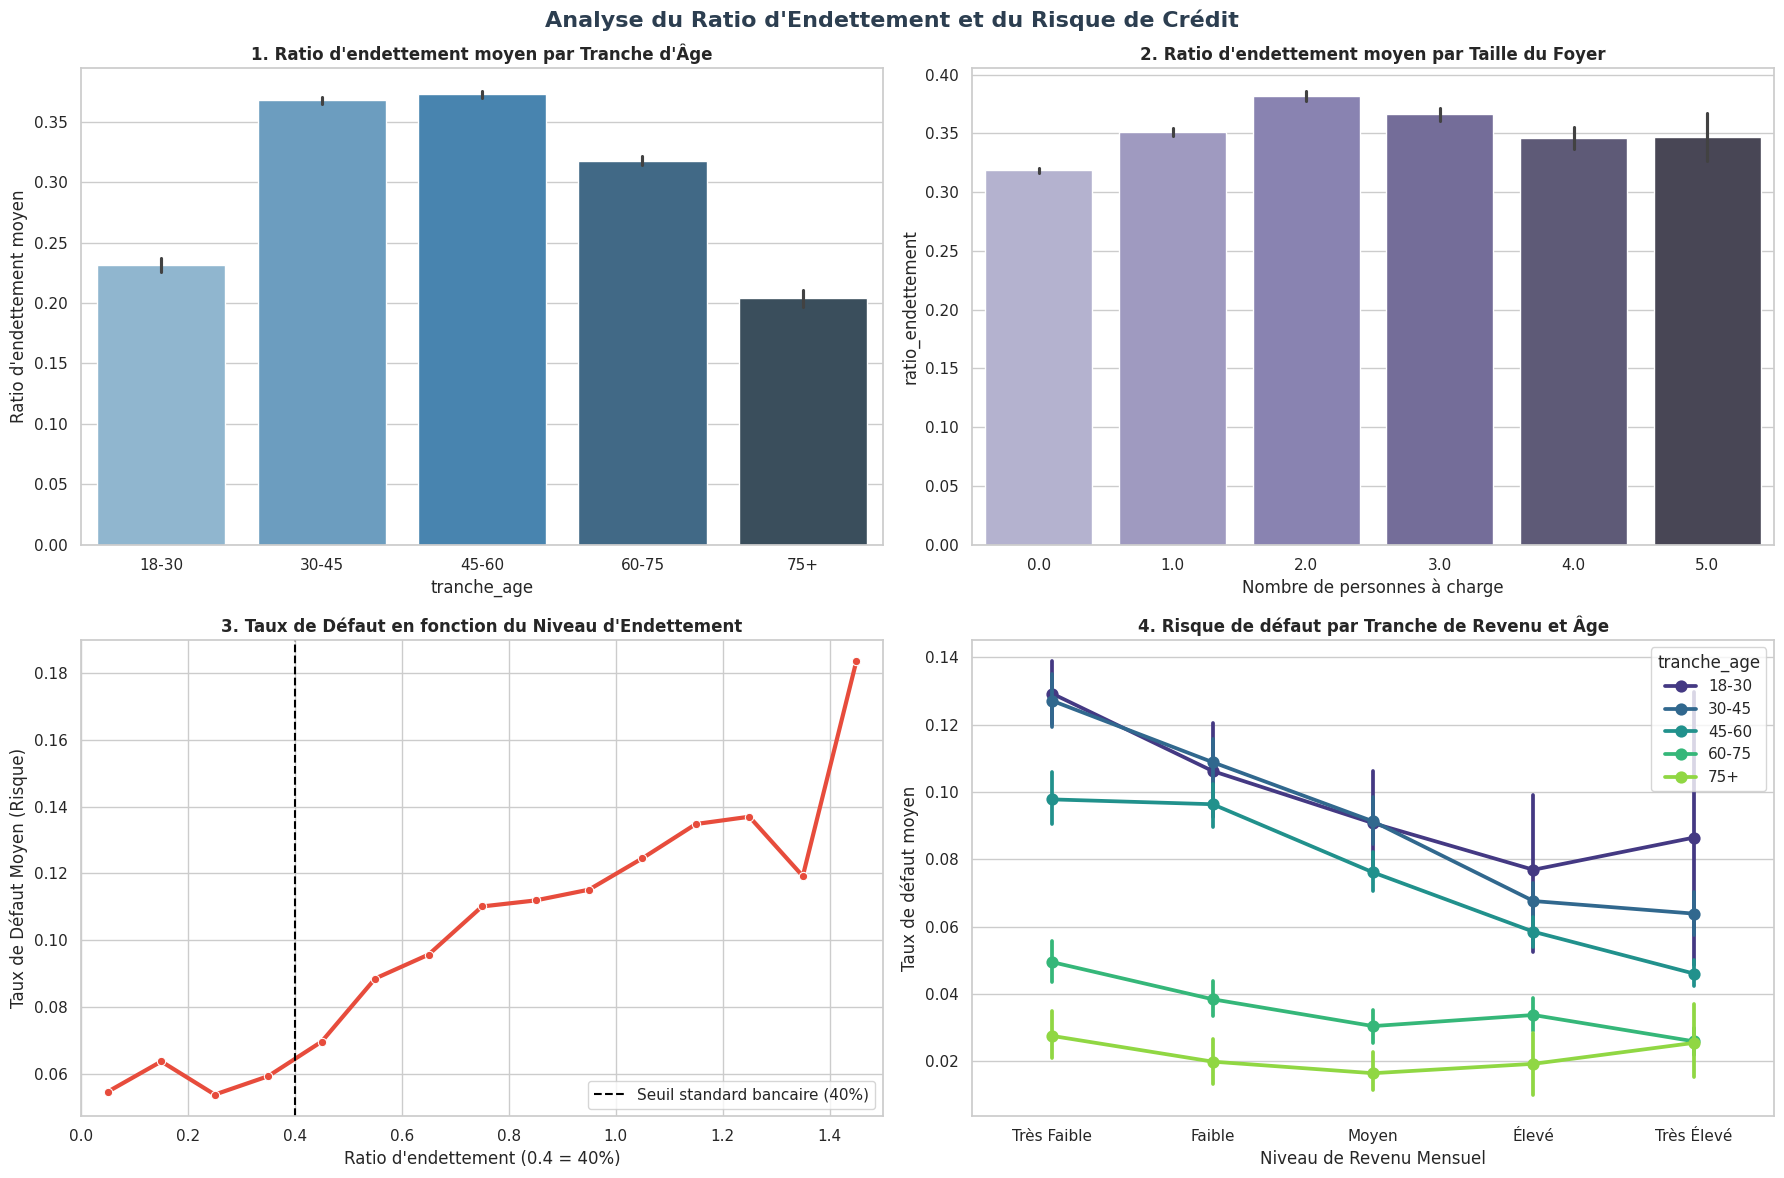

In [21]:
# On filtre pour ne garder que les lignes réalistes (ex: ratio d'endettement entre 0 et 2 pour l'analyse visuelle)
# car les valeurs géantes (ex: 3000) correspondent à la dette absolue lorsque le revenu est manquant.
df_analyse = data_score_credit[(data_score_credit['ratio_endettement'] <= 2) & (data_score_credit['Revenus_mensuel'] > 0)].copy()

# 1. Création des tranches d'âge et de revenus pour l'analyse groupée
df_analyse['tranche_age'] = pd.cut(df_analyse['age'], bins=[18, 30, 45, 60, 75, 100], labels=['18-30', '30-45', '45-60', '60-75', '75+'])
df_analyse['tranche_revenu'] = pd.qcut(df_analyse['Revenus_mensuel'], q=5, labels=['Très Faible', 'Faible', 'Moyen', 'Élevé', 'Très Élevé'])

# Configuration de la grille de graphiques (2 lignes, 2 colonnes)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Analyse du Ratio d'Endettement et du Risque de Crédit", fontsize=16, fontweight='bold', color='#2c3e50')

# --- Graphique 1 : Ratio d'endettement moyen par tranche d'âge ---
sns.barplot(data=df_analyse, x='tranche_age', y='ratio_endettement', palette='Blues_d', ax=axes[0, 0])
axes[0, 0].set_title("1. Ratio d'endettement moyen par Tranche d'Âge", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Ratio d'endettement moyen")

# --- Graphique 2 : Ratio d'endettement moyen par nombre de personnes à charge ---
# On limite à 5 personnes max à charge pour la lisibilité
sns.barplot(data=df_analyse[df_analyse['nbr_person_foyer'] <= 5], x='nbr_person_foyer', y='ratio_endettement', palette='Purples_d', ax=axes[0, 1])
axes[0, 1].set_title("2. Ratio d'endettement moyen par Taille du Foyer", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Nombre de personnes à charge")

# --- Graphique 3 : CORRIGÉ (Les personnes très endettées remboursent-elles bien ?) ---

# 1. On crée des tranches de ratio d'endettement propres (ex: de 0 à 1.5 avec un pas de 0.1)
df_analyse['tranche_endettement'] = pd.cut(df_analyse['ratio_endettement'], 
                                            bins=np.arange(0, 1.6, 0.1))

# 2. On calcule le taux de défaut moyen pour CHACUNE de ces tranches
df_grouped = df_analyse.groupby('tranche_endettement')['target'].mean().reset_index()

# 3. On convertit les tranches en chaînes de caractères ou en float pour l'affichage x
# Pour garder une belle courbe continue, on prend le milieu de chaque tranche
df_grouped['milieu_tranche'] = df_grouped['tranche_endettement'].apply(lambda x: x.mid if pd.notnull(x) else np.nan)

# 4. On trace une ligne PROPRE sans ombre
sns.lineplot(data=df_grouped, x='milieu_tranche', y='target', color='#e74c3c', marker='o', lw=3, ax=axes[1, 0])

axes[1, 0].set_title("3. Taux de Défaut en fonction du Niveau d'Endettement", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Ratio d'endettement (0.4 = 40%)")
axes[1, 0].set_ylabel("Taux de Défaut Moyen (Risque)")
axes[1, 0].set_xlim(0, 1.5) # On limite à 1.5 pour bien voir la zone critique

# Ligne du seuil bancaire
axes[1, 0].axvline(0.4, color='black', linestyle='--', label='Seuil standard bancaire (40%)')
axes[1, 0].legend()

# --- Graphique 4 : Existe-t-il un seuil de revenu où le risque d'endettement diminue ? ---
sns.pointplot(data=df_analyse, x='tranche_revenu', y='target', hue='tranche_age', palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title("4. Risque de défaut par Tranche de Revenu et Âge", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Niveau de Revenu Mensuel")
axes[1, 1].set_ylabel("Taux de défaut moyen")

plt.tight_layout()
plt.show()

# Analyste avancé sur facture de risque et score de credit

/tmp/ipykernel_1491666/1662427186.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_visu, x='a_pret_immobilier', y='target', palette='Set2', ax=axes[0, 1])
/tmp/ipykernel_1491666/1662427186.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_visu[df_visu['nbr_30-59_jours_retard'] <= 5],
/tmp/ipykernel_1491666/1662427186.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_visu[df_visu['nbr_90_jours_retard'] <= 4],


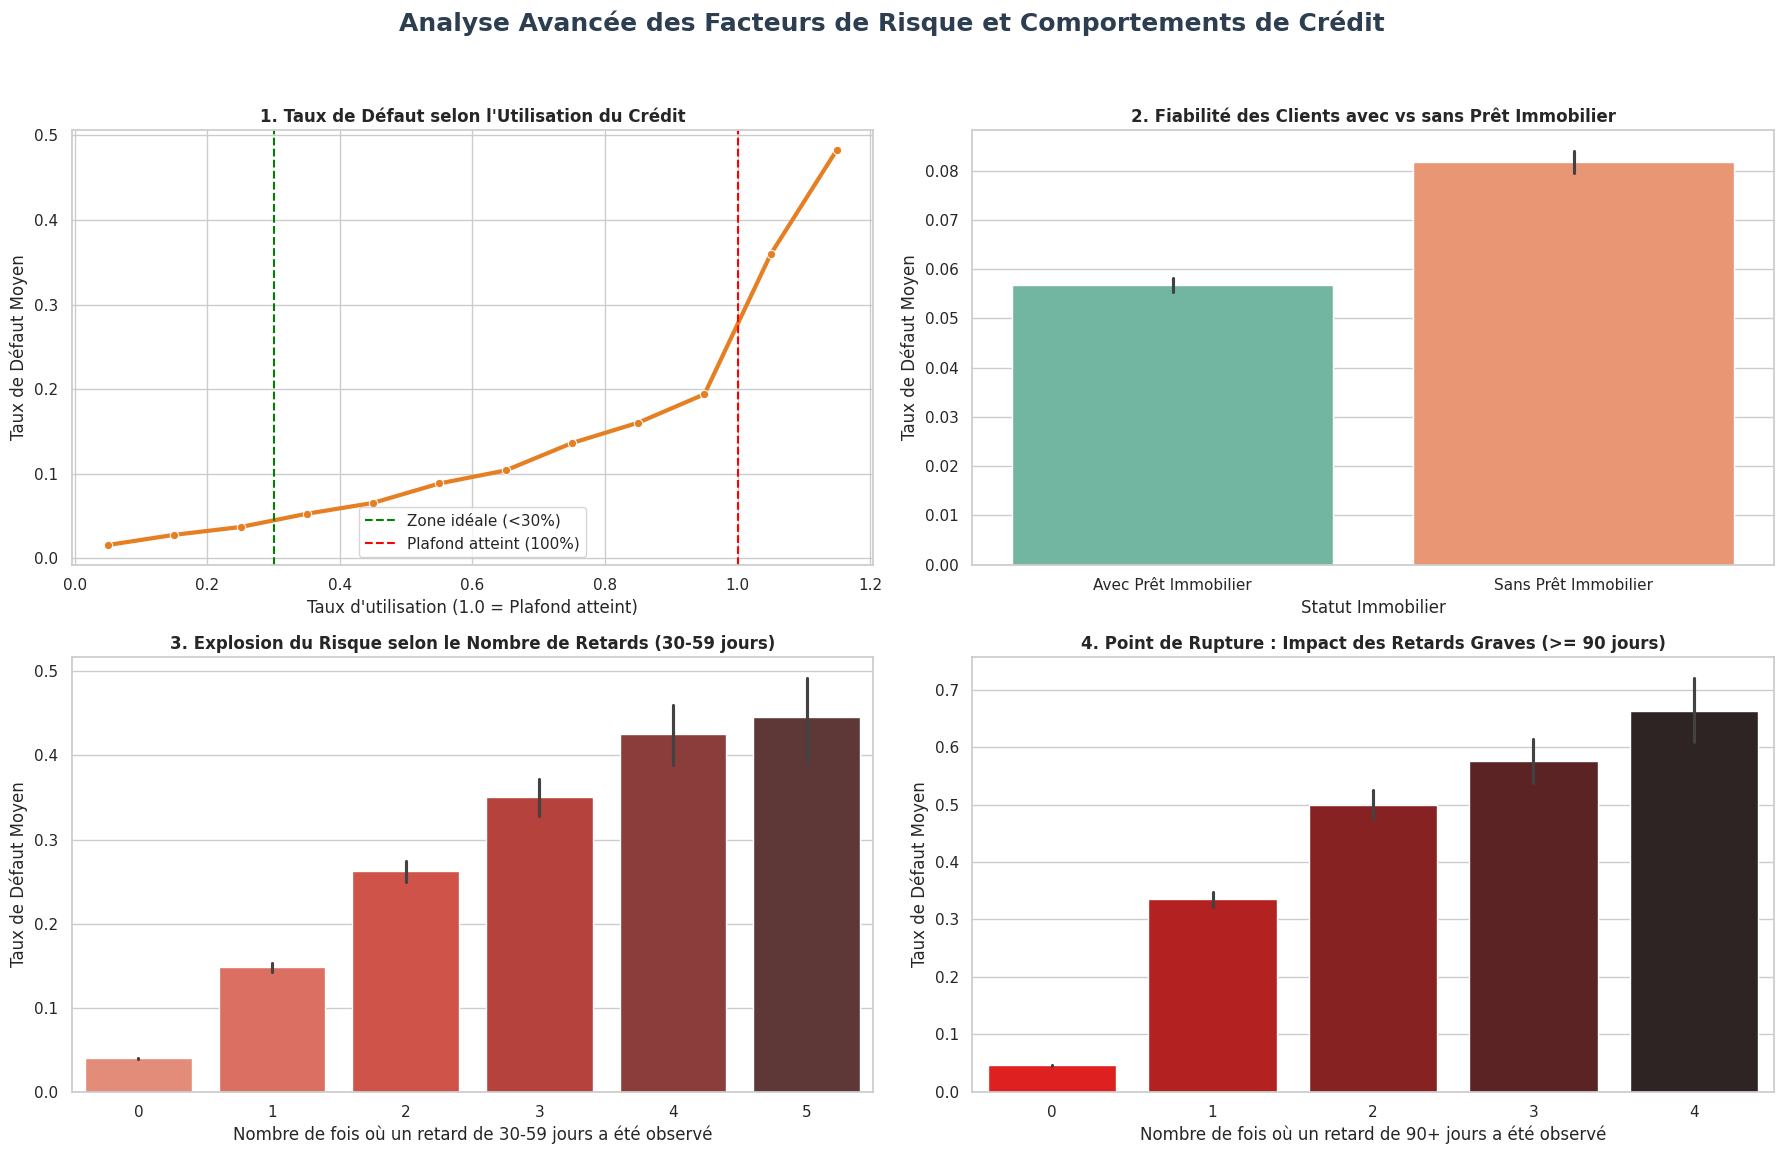

In [22]:
# Configurer le style des graphiques
sns.set_theme(style="whitegrid")

# On crée une copie propre pour l'affichage en filtrant les aberrations du taux d'utilisation
# (On limite le taux d'utilisation à 1.5 pour le visuel, car certaines valeurs aberrantes vont au-delà)
df_visu = data_score_credit[data_score_credit['taux_utilisation_credit'] <= 1.5].copy()

# Préparation des tranches pour le Graphique 1 (Taux d'utilisation)
df_visu['tranche_utilisation'] = pd.cut(df_visu['taux_utilisation_credit'], 
                                        bins=np.arange(0, 1.3, 0.1))
df_grouped_util = df_visu.groupby('tranche_utilisation', observed=False)['target'].mean().reset_index()
df_grouped_util['milieu_tranche'] = df_grouped_util['tranche_utilisation'].apply(lambda x: x.mid if pd.notnull(x) else np.nan)

# Initialisation de la grille 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Analyse Avancée des Facteurs de Risque et Comportements de Crédit", 
             fontsize=18, fontweight='bold', color='#2c3e50', y=0.96)

# --- [0, 0] Q1 : Risque selon le Taux d'Utilisation des Lignes de Crédit ---
sns.lineplot(data=df_grouped_util, x='milieu_tranche', y='target', color='#e67e22', marker='o', lw=3, ax=axes[0, 0])
axes[0, 0].set_title("1. Taux de Défaut selon l'Utilisation du Crédit", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Taux d'utilisation (1.0 = Plafond atteint)")
axes[0, 0].set_ylabel("Taux de Défaut Moyen")
axes[0, 0].axvline(0.3, color='green', linestyle='--', label='Zone idéale (<30%)')
axes[0, 0].axvline(1.0, color='red', linestyle='--', label='Plafond atteint (100%)')
axes[0, 0].legend()

# --- [0, 1] Q2 : Impact de la possession d'un Prêt Immobilier ---
# On crée une variable binaire : a un prêt immo (>=1) ou n'en a pas (0)
df_visu['a_pret_immobilier'] = np.where(df_visu['nbr_prets_immobilier'] > 0, 'Avec Prêt Immobilier', 'Sans Prêt Immobilier')
sns.barplot(data=df_visu, x='a_pret_immobilier', y='target', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title("2. Fiabilité des Clients avec vs sans Prêt Immobilier", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Statut Immobilier")
axes[0, 1].set_ylabel("Taux de Défaut Moyen")

# --- [1, 0] Q3 : Impact de l'historique des retards légers (30-59 jours) ---
# On limite l'affichage à 5 retards maximum pour éviter le bruit des valeurs extrêmes
sns.barplot(data=df_visu[df_visu['nbr_30-59_jours_retard'] <= 5], 
            x='nbr_30-59_jours_retard', y='target', palette='Reds_d', ax=axes[1, 0])
axes[1, 0].set_title("3. Explosion du Risque selon le Nombre de Retards (30-59 jours)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Nombre de fois où un retard de 30-59 jours a été observé")
axes[1, 0].set_ylabel("Taux de Défaut Moyen")

# --- [1, 1] Q4 : Le point de rupture des retards graves (90 jours ou plus) ---
# On limite à 4 retards max pour la clarté du graphique
sns.barplot(data=df_visu[df_visu['nbr_90_jours_retard'] <= 4], 
            x='nbr_90_jours_retard', y='target', palette='dark:red_r', ax=axes[1, 1])
axes[1, 1].set_title("4. Point de Rupture : Impact des Retards Graves (>= 90 jours)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Nombre de fois où un retard de 90+ jours a été observé")
axes[1, 1].set_ylabel("Taux de Défaut Moyen")

# Ajustement des espaces
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# Implémentation du modèle machine learning

In [23]:
def nettoyage(data):
    data = data.fillna(data.median())
    data = data.drop_duplicates()
    return data

In [24]:
data = nettoyage(data_score_credit)
data.head()

,Unnamed: 0,target,taux_utilisation_credit,age,nbr_30-59_jours_retard,ratio_endettement,Revenus_mensuel,nbr_lignes_credit_ouvertes,nbr_90_jours_retard,nbr_prets_immobilier,nbr_60-89_jours_retard,nbr_person_foyer
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [25]:
X = data.drop(columns=['target','Unnamed: 0'])
y = data['target']


In [26]:
cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=42)
X_train,X_test,Y_train,Y_test = train_test_split(X,
                                                 y, 
                                                 random_state=42,
                                                 test_size=0.20,
                                                 stratify=y)

model = RandomForestClassifier(n_estimators=100,
                               max_depth=10,
                               random_state=42,
                               class_weight='balanced')
score = cross_val_score(model,X_train,Y_train,cv=cv, scoring='roc_auc')
model.fit(X_train,Y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(Y_test,y_pred)

# Visualisation de ma matrice de confusion

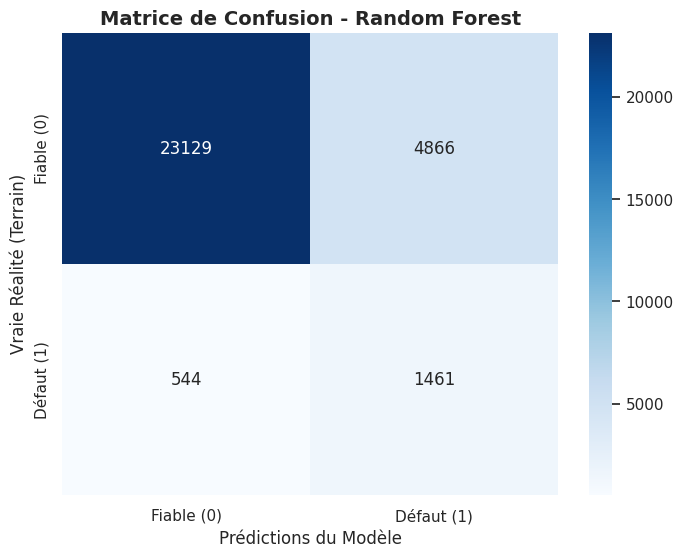

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fiable (0)", "Défaut (1)"],
    yticklabels=["Fiable (0)", "Défaut (1)"],
)
plt.title(
    "Matrice de Confusion - Random Forest", fontsize=14, fontweight="bold"
)
plt.xlabel("Prédictions du Modèle")
plt.ylabel("Vraie Réalité (Terrain)")
plt.show()

# Visualisation de ma validation croisée

/tmp/ipykernel_1491666/1019500663.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plis, y=score, palette="Blues_d", ax=axes[0])


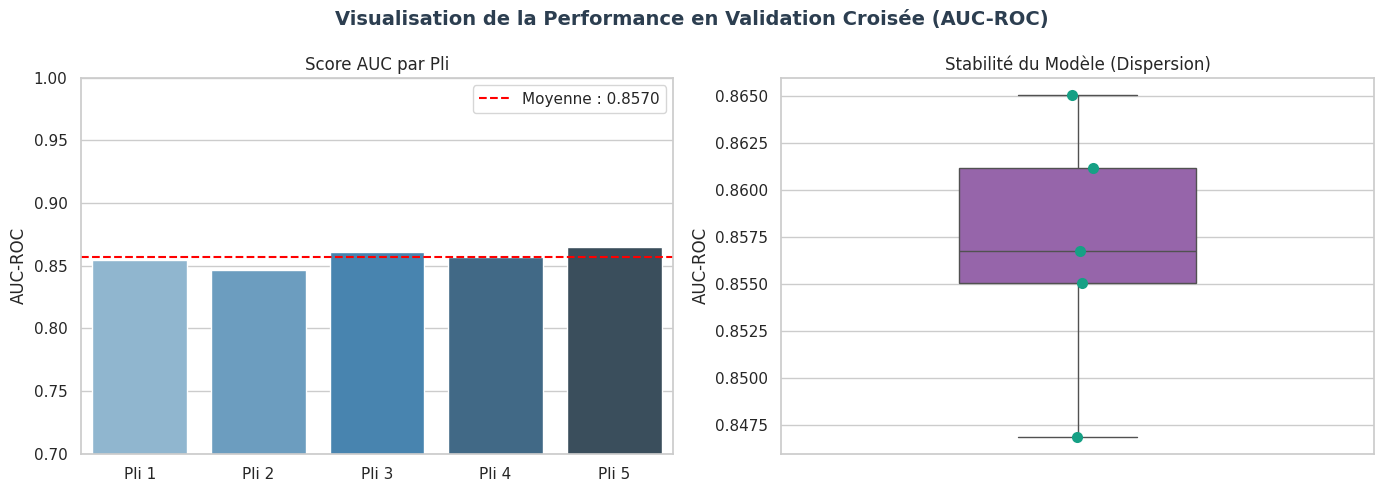

In [28]:
# Création d'une grille avec 2 graphiques côte à côte
fig, axes = plt.subplots(1,2, figsize=(14, 5))
fig.suptitle("Visualisation de la Performance en Validation Croisée (AUC-ROC)", 
             fontsize=14, fontweight='bold', color='#2c3e50')

# --- Graphique 1 : Les scores de chaque Pli (Fold) ---
plis = [f"Pli {i+1}" for i in range(len(score))]
sns.barplot(x=plis, y=score, palette="Blues_d", ax=axes[0])
axes[0].set_title("Score AUC par Pli")
axes[0].set_ylabel("AUC-ROC")
axes[0].set_ylim(0.7, 1.0) # On zoome sur la zone intéressante (ajuste selon tes scores)

# Ajout de la ligne moyenne pour référence
mean_auc = score.mean()
axes[0].axhline(mean_auc, color='red', linestyle='--', label=f'Moyenne : {mean_auc:.4f}')
axes[0].legend()

# --- Graphique 2 : Dispersion et Stabilité (Boxplot) ---
sns.boxplot(y=score, color="#9b59b6", width=0.4, ax=axes[1])
sns.stripplot(y=score, color="#16a085", size=8, jitter=0.05, ax=axes[1]) # Ajoute les vrais points
axes[1].set_title("Stabilité du Modèle (Dispersion)")
axes[1].set_ylabel("AUC-ROC")

plt.tight_layout()
plt.show()

# Optimisation du modèle

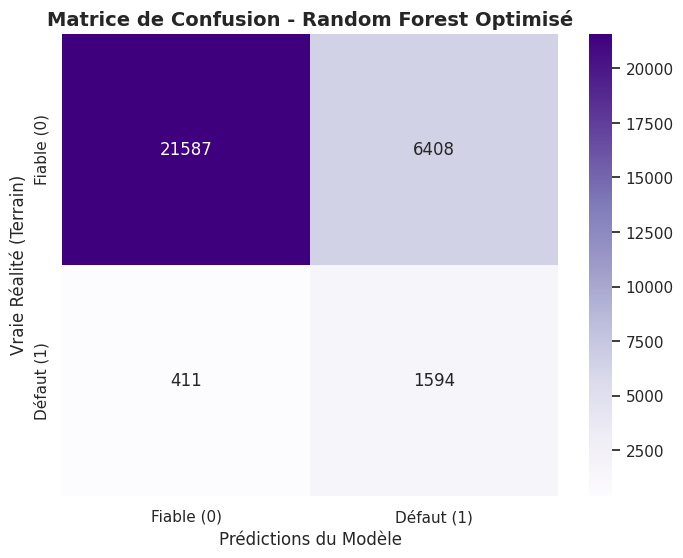

In [29]:
param_grid = {
    'max_depth': [5, 10, 15],
    'n_estimators': [50, 100, 200]
}

# 2. Configuration de la recherche par grille avec notre stratégie 'cv' (StratifiedKFold)
grid_search = GridSearchCV(
    estimator=model, # Ton modèle Random Forest actuel
    param_grid=param_grid, 
    cv=cv,           # Ta validation croisée à 5 plis
    scoring='roc_auc', 
    n_jobs=-1        # Utilise tous les c?urs de ton processeur
)

# 3. Entraînement et optimisation automatique
grid_search.fit(X_train, Y_train)
# 5. Extraction du meilleur modèle optimisé
best_rf_model = grid_search.best_estimator_

# 6. Évaluation finale sur le Test Set avec le modèle optimisé
y_pred_opt = best_rf_model.predict(X_test)
cm_opt = confusion_matrix(Y_test, y_pred_opt)

# 7. Affichage de la nouvelle Matrice de Confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Purples",
            xticklabels=['Fiable (0)', 'Défaut (1)'],
            yticklabels=['Fiable (0)', 'Défaut (1)'])
plt.title("Matrice de Confusion - Random Forest Optimisé", fontsize=14, fontweight='bold')
plt.xlabel("Prédictions du Modèle")
plt.ylabel("Vraie Réalité (Terrain)")
plt.show()

# Implementation du XGBOOST

[[20262  7733]
 [  311  1694]]


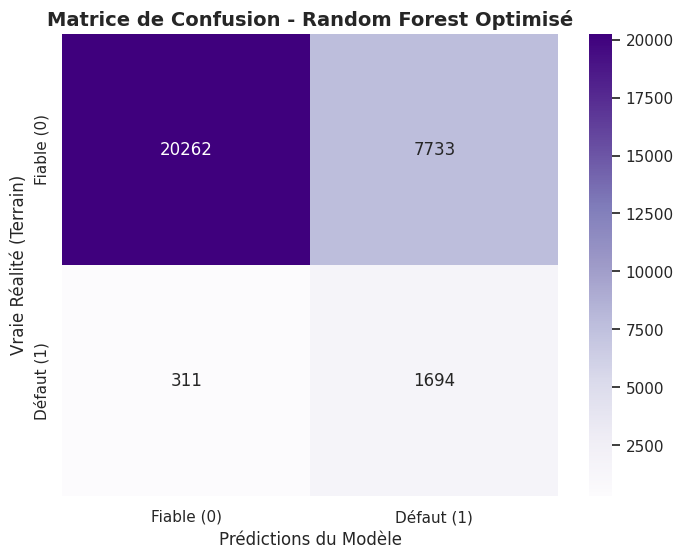

In [31]:
# 1. Calcul du ratio pour gérer le déséquilibre des classes (Imbalanced Data)
# On compte combien de "0" on a pour un "1" pour guider le paramètre scale_pos_weight
num_neg = (Y_train == 0).sum()
num_pos = (Y_train == 1).sum()
class_ratio = num_neg / num_pos

# 1. On entraîne XGBoost avec un scale_pos_weight standard (class_ratio normal)
xgb_model = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    scale_pos_weight=class_ratio, random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_model.fit(X_train, Y_train)

# 2. Au lieu de faire .predict(), on récupère les probabilités brutes
y_probas = xgb_model.predict_proba(X_test)[:, 1]

# 3. On ajuste le seuil manuellement (Ajuste cette valeur pour équilibrer FN et FP)
seuil_personnalise = 0.40 
y_pred_ajuste = (y_probas >= seuil_personnalise).astype(int)

# 4. Affiche la nouvelle matrice
xgb = confusion_matrix(Y_test, y_pred_ajuste)
print(xgb)

# 7. Affichage de la nouvelle Matrice de Confusion
plt.figure(figsize=(8, 6))
sns.heatmap(xgb, annot=True, fmt="d", cmap="Purples",
            xticklabels=['Fiable (0)', 'Défaut (1)'],
            yticklabels=['Fiable (0)', 'Défaut (1)'])
plt.title("Matrice de Confusion - Random Forest Optimisé", fontsize=14, fontweight='bold')
plt.xlabel("Prédictions du Modèle")
plt.ylabel("Vraie Réalité (Terrain)")
plt.show()